<a href="https://colab.research.google.com/github/kamiyapuziko/ML-Labi/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# МЛ Практика 2: Статистика в действии и её влияние на модель

## **Цель занятия:**
Изучить, как статистические метрики (среднее, медиана, квантили, размер выборки, стандартное отклонение) влияют на анализ данных и построение моделей машинного обучения. На практике мы проведем анализ целевой переменной **Y**, обучим модель линейной регрессии и исследуем влияние статистических характеристик на метрики модели.

## **Задание состоит из следующих частей:**
1. Анализ целевой переменной **Y** с точки зрения статистики. (в нашем случае - бинарная классификация)
2. Анализ пропусков
2. Изучение влияния статистических метрик на данные.
3. Обучение модели линейной регрессии и оценка ее точности.
4. Проведение теста Пирсона.
5. Визуализация результатов и анализ влияния статистики на метрики модели.
6. Валидация модели
---

## 1. Анализ целевой переменной Y с точки зрения статистики

### **Описание:**
В этом разделе вы проведете статистический анализ целевой переменной **Y**, изучите ее распределение и основные статистические характеристики.

1. **Импортируйте необходимые библиотеки:**

In [62]:
!pip install pandas scikit-learn seaborn scipy

In [63]:
   import pandas as pd
   import numpy as np
   import matplotlib.pyplot as plt
   import seaborn as sns
   from scipy import stats

2. **Загружаем набор данных:**

In [64]:
# Загрузка набора данных
df = pd.read_csv('/content/heart.csv')

In [65]:
df

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
0,42,1,110,65,64,147,291,2,8,4,120,78,271,146,2,1
1,53,1,130,72,69,167,278,1,6,2,122,68,250,165,9,1
2,53,2,120,90,70,222,342,4,8,1,132,90,304,223,2,1
3,48,4,120,80,72,229,239,4,8,2,118,68,209,227,3,1
4,53,3,118,74,66,134,243,3,8,5,118,56,261,138,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,50,1,115,80,66,148,300,2,8,1,115,65,273,152,0,0
196,23,1,110,70,69,137,120,3,8,2,112,76,198,153,0,0
197,20,3,130,80,66,150,210,5,0,1,130,85,274,158,0,0
198,46,3,140,84,66,138,130,4,6,2,148,88,160,157,0,0


In [66]:
# для удобства распечатаем все колонки
for column in df.columns:
  print(f'колонка: {column}')

колонка: AGE_50
колонка: MD_50
колонка: SBP_50
колонка: DBP_50
колонка: HT_50
колонка: WT_50
колонка: CHOL_50
колонка: SES
колонка: CL_STATUS
колонка: MD_62
колонка: SBP_62
колонка: DBP_62
колонка: CHOL_62
колонка: WT_62
колонка: IHD_DX
колонка: DEATH


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AGE_50     200 non-null    int64
 1   MD_50      200 non-null    int64
 2   SBP_50     200 non-null    int64
 3   DBP_50     200 non-null    int64
 4   HT_50      200 non-null    int64
 5   WT_50      200 non-null    int64
 6   CHOL_50    200 non-null    int64
 7   SES        200 non-null    int64
 8   CL_STATUS  200 non-null    int64
 9   MD_62      200 non-null    int64
 10  SBP_62     200 non-null    int64
 11  DBP_62     200 non-null    int64
 12  CHOL_62    200 non-null    int64
 13  WT_62      200 non-null    int64
 14  IHD_DX     200 non-null    int64
 15  DEATH      200 non-null    int64
dtypes: int64(16)
memory usage: 25.1 KB


3. **Проверьте наличие пропущенных значений и работа с пропусками для числовых:**

In [68]:
# Проверка на пропущенные значения
print(df.isnull().sum()) # пропусков нет

AGE_50       0
MD_50        0
SBP_50       0
DBP_50       0
HT_50        0
WT_50        0
CHOL_50      0
SES          0
CL_STATUS    0
MD_62        0
SBP_62       0
DBP_62       0
CHOL_62      0
WT_62        0
IHD_DX       0
DEATH        0
dtype: int64


In [69]:
# генерируем случайную последовательность
np.random.seed(42)
df_test_nan = df.copy()
df_test_nan.loc[np.random.choice(df_test_nan.index, size=5, replace=True), 'SES'] = np.nan

In [70]:
# Проверка на пропущенные значения
print(df_test_nan.isnull().sum()) # пропусков нет

AGE_50       0
MD_50        0
SBP_50       0
DBP_50       0
HT_50        0
WT_50        0
CHOL_50      0
SES          5
CL_STATUS    0
MD_62        0
SBP_62       0
DBP_62       0
CHOL_62      0
WT_62        0
IHD_DX       0
DEATH        0
dtype: int64


In [71]:
# Вариант 1: Удаление строк с пропусками
df_drop = df_test_nan.dropna()
print("\n# Удаление строк с пропусками")
print(df.isnull().sum()) # пропусков нет


# Удаление строк с пропусками
AGE_50       0
MD_50        0
SBP_50       0
DBP_50       0
HT_50        0
WT_50        0
CHOL_50      0
SES          0
CL_STATUS    0
MD_62        0
SBP_62       0
DBP_62       0
CHOL_62      0
WT_62        0
IHD_DX       0
DEATH        0
dtype: int64


In [72]:
# Вариант 2: Заполнение пропусков медианой
df_median = df_test_nan.copy()
df_median.SES = df_median.SES.fillna(df_median.SES.median())

print("\n# Заполнение пропусков медианой")
print(df_median.isnull().sum()) # пропусков нет


# Заполнение пропусков медианой
AGE_50       0
MD_50        0
SBP_50       0
DBP_50       0
HT_50        0
WT_50        0
CHOL_50      0
SES          0
CL_STATUS    0
MD_62        0
SBP_62       0
DBP_62       0
CHOL_62      0
WT_62        0
IHD_DX       0
DEATH        0
dtype: int64


In [73]:
# Вариант 3: Заполнение пропусков средним
df_mean = df_test_nan.copy()
df_mean.SES = df_mean.SES.fillna(df_median.SES.mean())

print("\n# Заполнение пропусков средним")
print(df_mean.isnull().sum()) # пропусков нет


# Заполнение пропусков средним
AGE_50       0
MD_50        0
SBP_50       0
DBP_50       0
HT_50        0
WT_50        0
CHOL_50      0
SES          0
CL_STATUS    0
MD_62        0
SBP_62       0
DBP_62       0
CHOL_62      0
WT_62        0
IHD_DX       0
DEATH        0
dtype: int64


⏰ Заполнение категориальных признаков происходит с помощью ```df.category_variable.mode() (как один из вариантов, хотя и считается недостаточно хорошим).```

Как вариант - можно использовать KNN (K-ближайших соедей)

4. **Выбираем целвую переменную**

⏰ В качестве целевой выбираем категориальную переменную, либо превращаем числовую в категориальное

```В моем датасете была выбрана целевая переменная is_alive -> которая была преобразована из DEATH (если значение = 0, то жив, иначе мертв)```

In [74]:
df['is_alive'] = np.where(df['DEATH'] > 0, 1, 0).astype(int)

In [75]:
df.columns

Index(['AGE_50', 'MD_50', 'SBP_50', 'DBP_50', 'HT_50', 'WT_50', 'CHOL_50',
       'SES', 'CL_STATUS', 'MD_62', 'SBP_62', 'DBP_62', 'CHOL_62', 'WT_62',
       'IHD_DX', 'DEATH', 'is_alive'],
      dtype='object')

In [76]:
Y = df['is_alive'] # выбираем целевую переменную (категориальную)
X = df.drop('is_alive', axis=1) # переменные для проверки влияния

# В моем случае я дропаю базовую переменную, а не только. Y
X = X.drop('DEATH', axis=1)

5. **Графический анализ**

In [77]:
# Список числовых колонок для построения графиков
numeric_cols = X.select_dtypes(include=['float64', 'int64'])
numeric_cols

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX
0,42,1,110,65,64,147,291,2,8,4,120,78,271,146,2
1,53,1,130,72,69,167,278,1,6,2,122,68,250,165,9
2,53,2,120,90,70,222,342,4,8,1,132,90,304,223,2
3,48,4,120,80,72,229,239,4,8,2,118,68,209,227,3
4,53,3,118,74,66,134,243,3,8,5,118,56,261,138,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,50,1,115,80,66,148,300,2,8,1,115,65,273,152,0
196,23,1,110,70,69,137,120,3,8,2,112,76,198,153,0
197,20,3,130,80,66,150,210,5,0,1,130,85,274,158,0
198,46,3,140,84,66,138,130,4,6,2,148,88,160,157,0


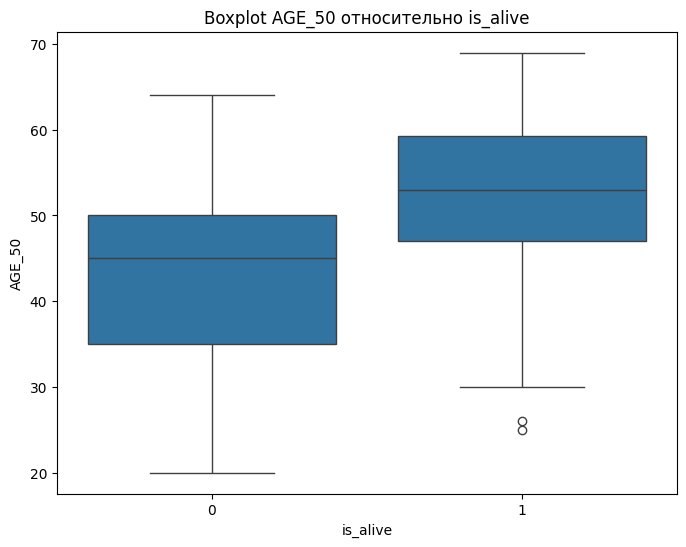

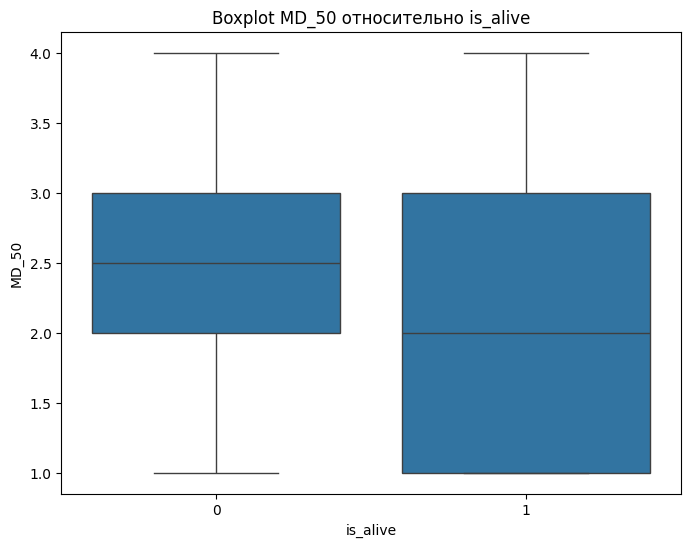

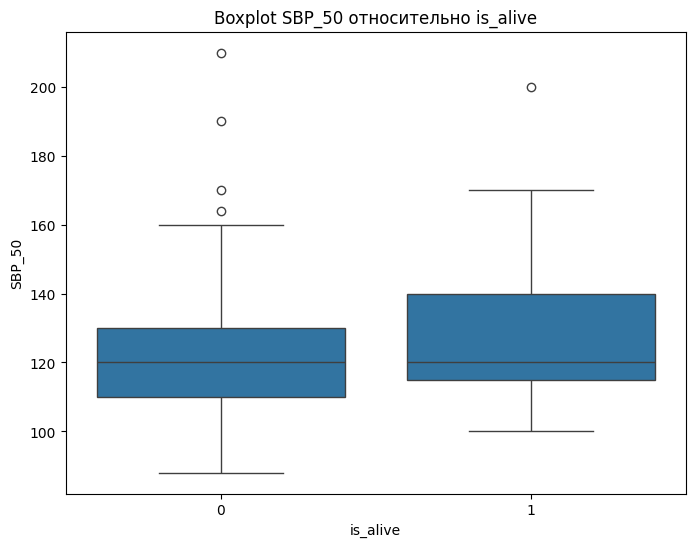

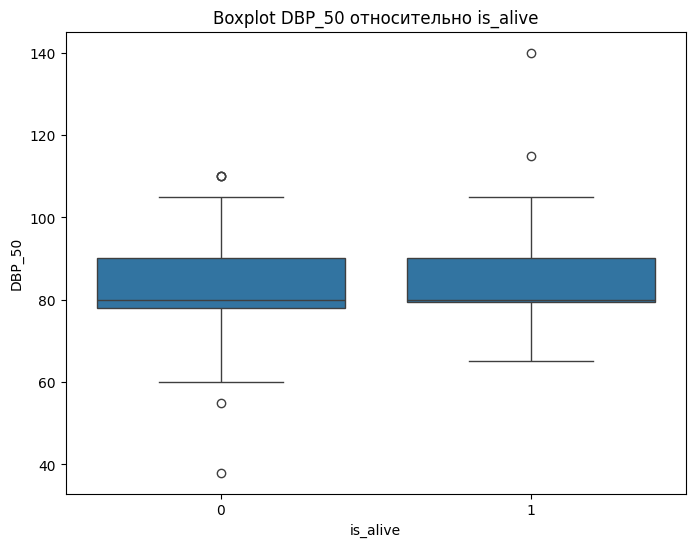

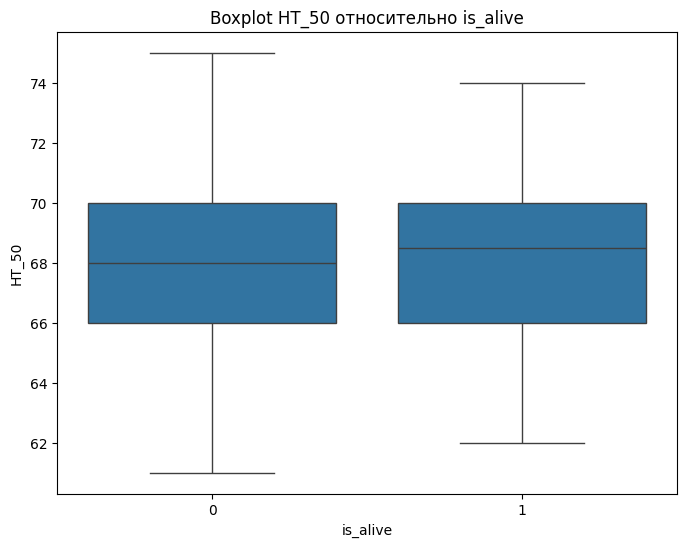

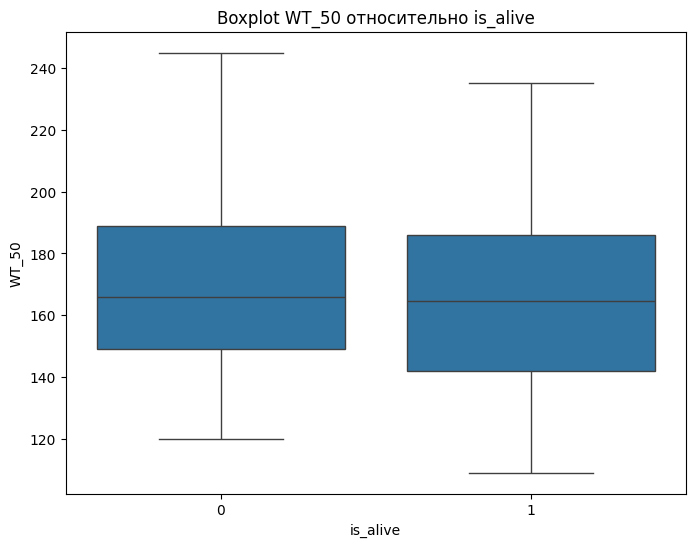

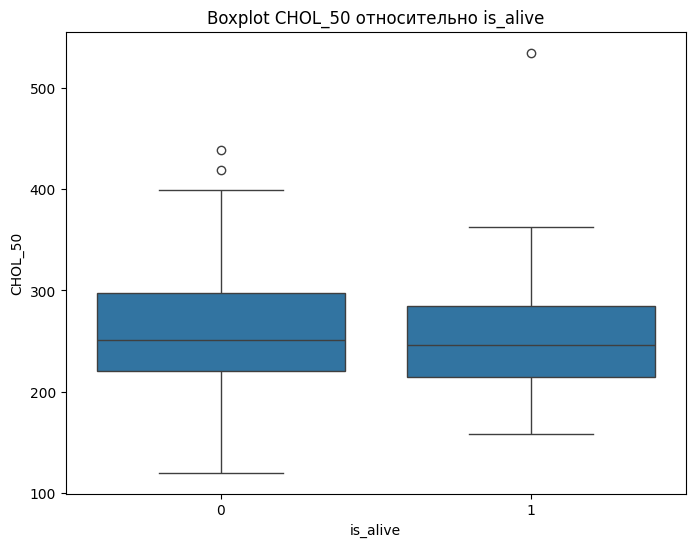

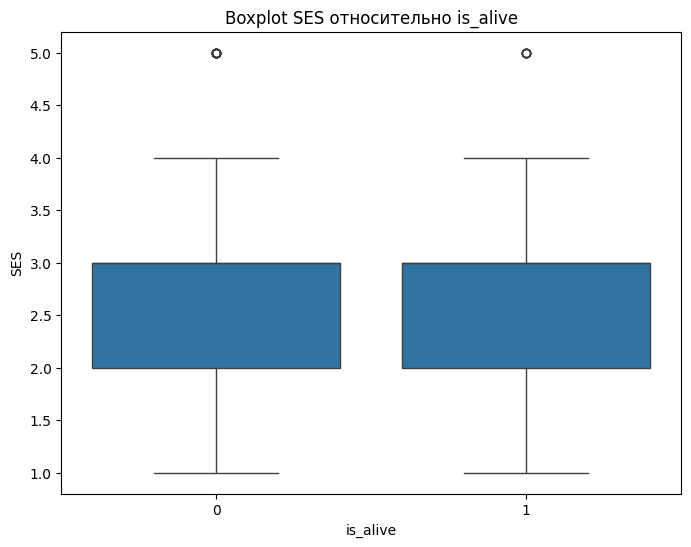

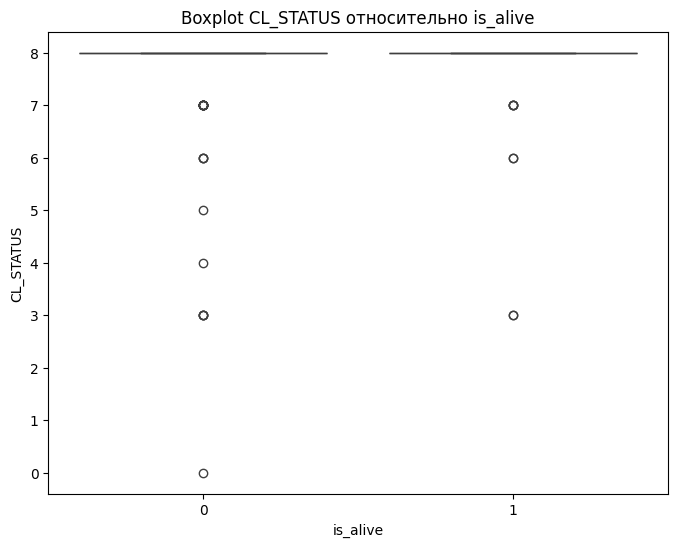

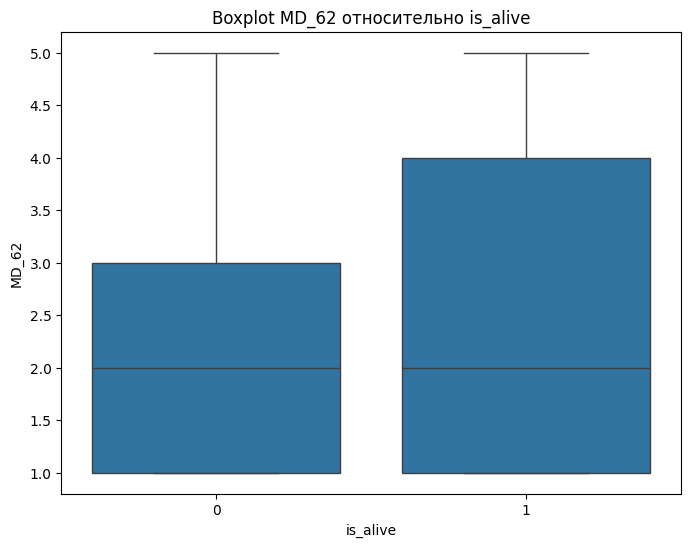

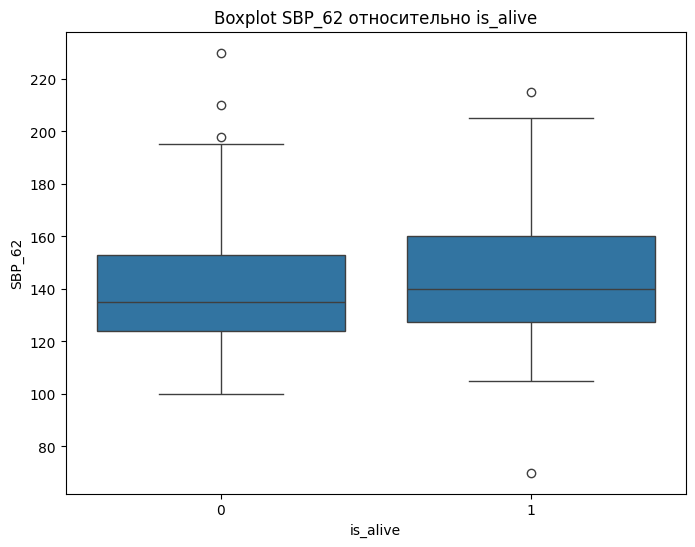

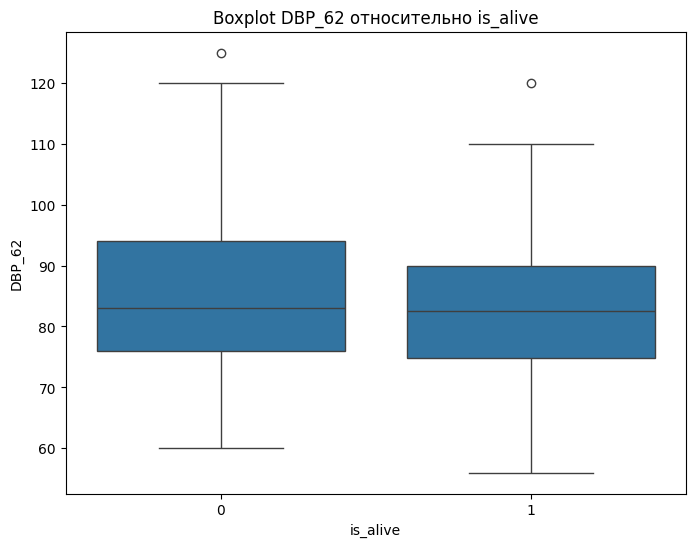

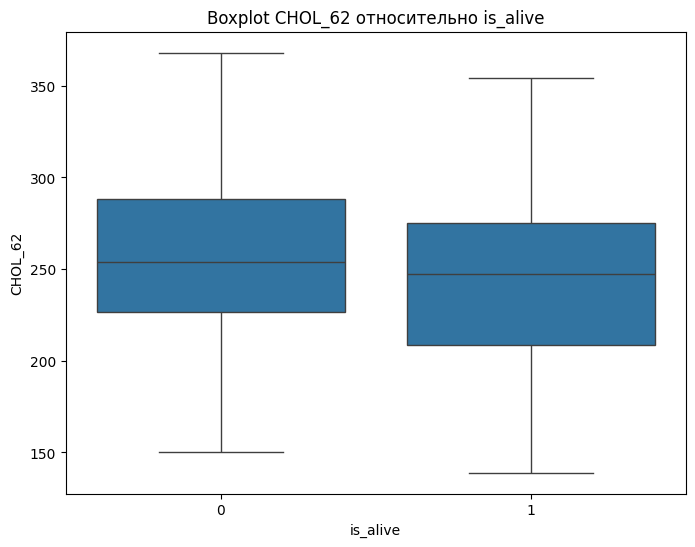

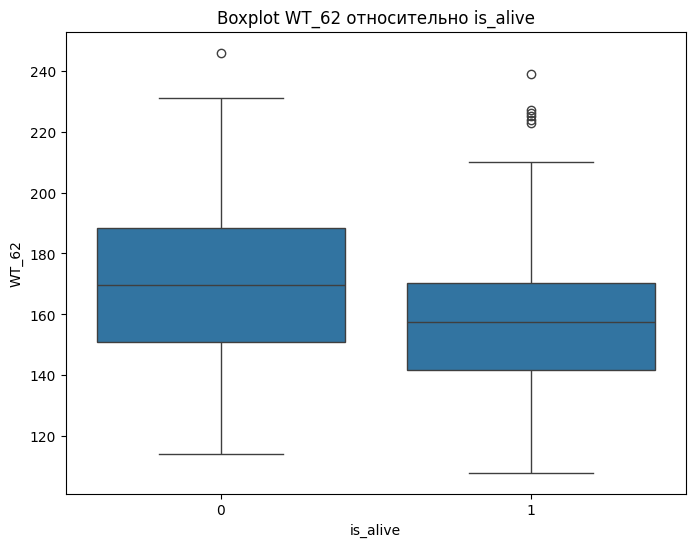

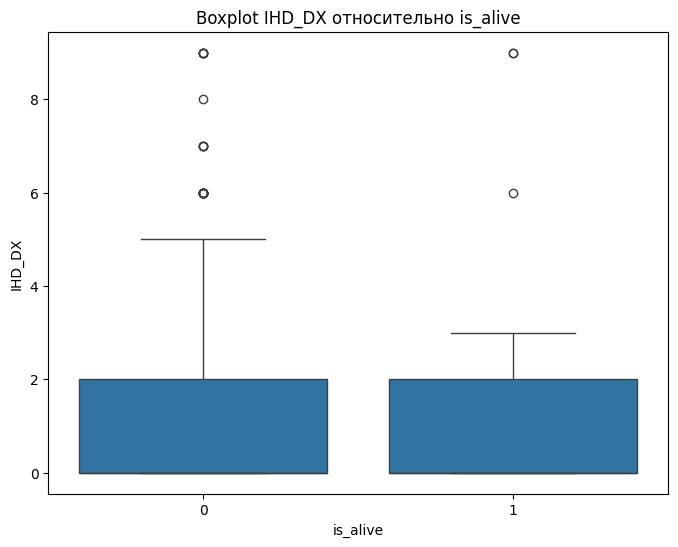

In [78]:
# Построение boxplot для каждой переменной
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='is_alive', y=col, data=df)
    plt.title(f'Boxplot {col} относительно is_alive')
    plt.show()

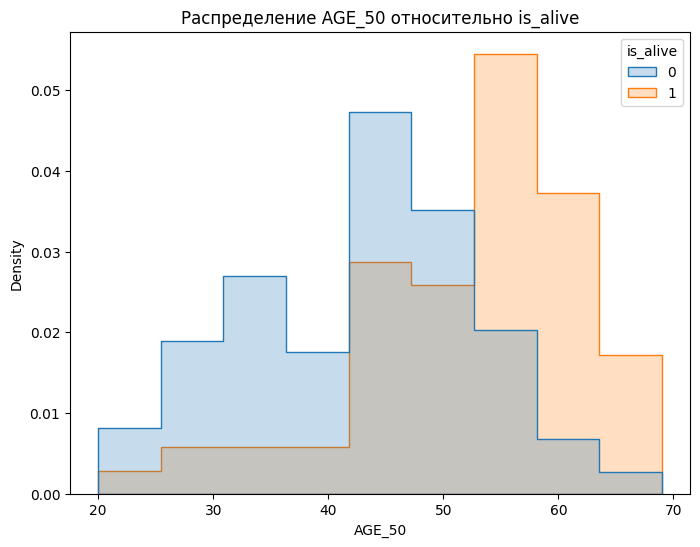

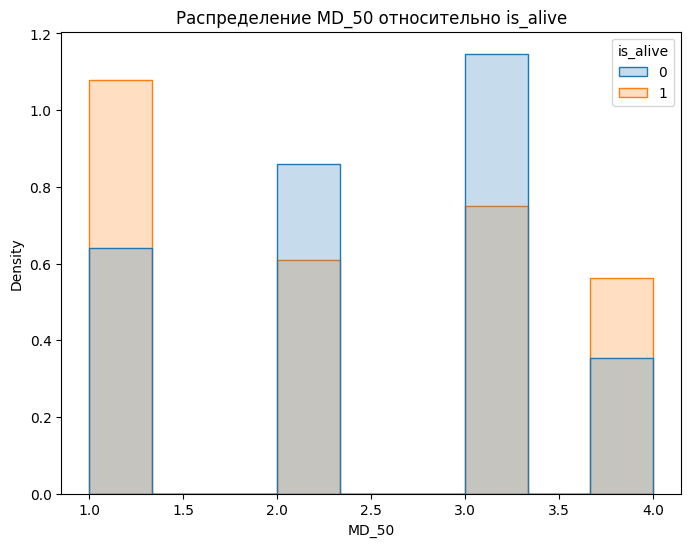

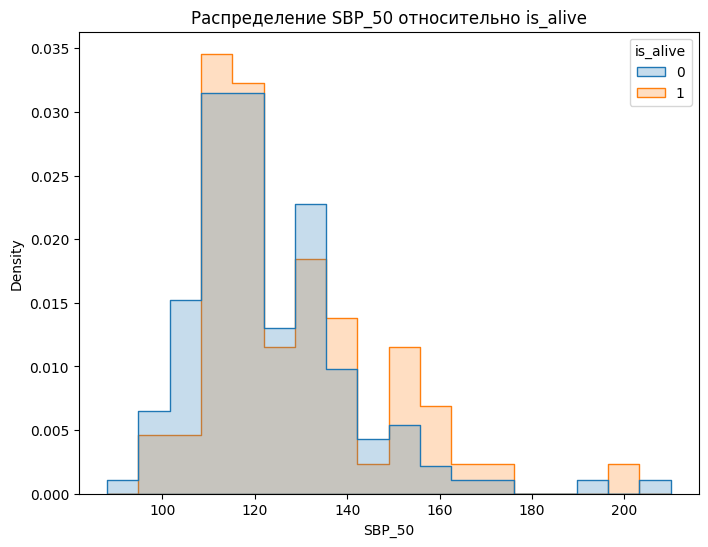

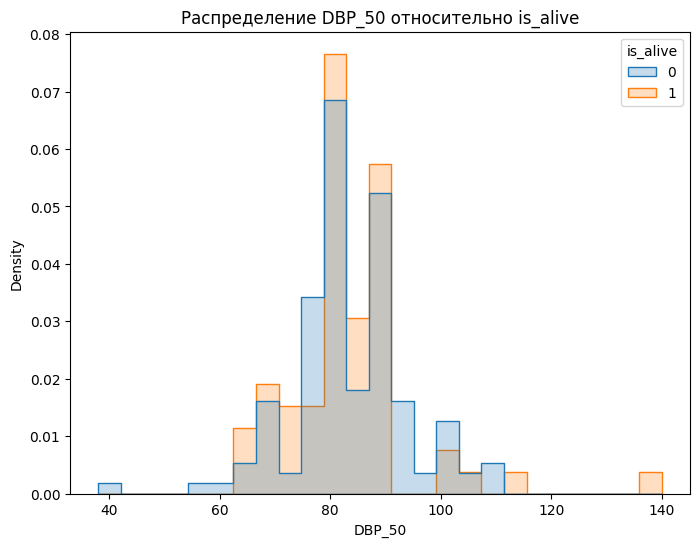

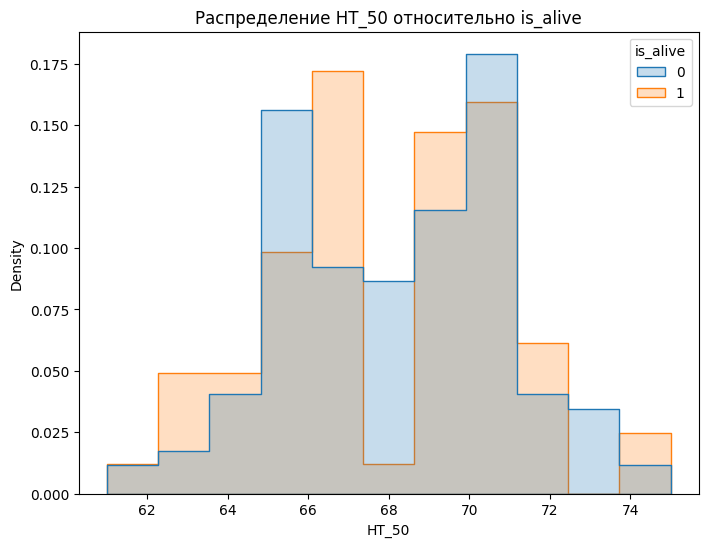

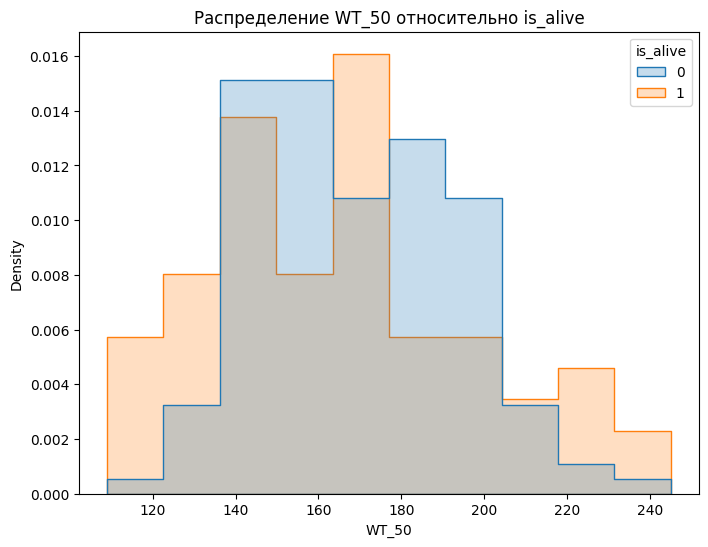

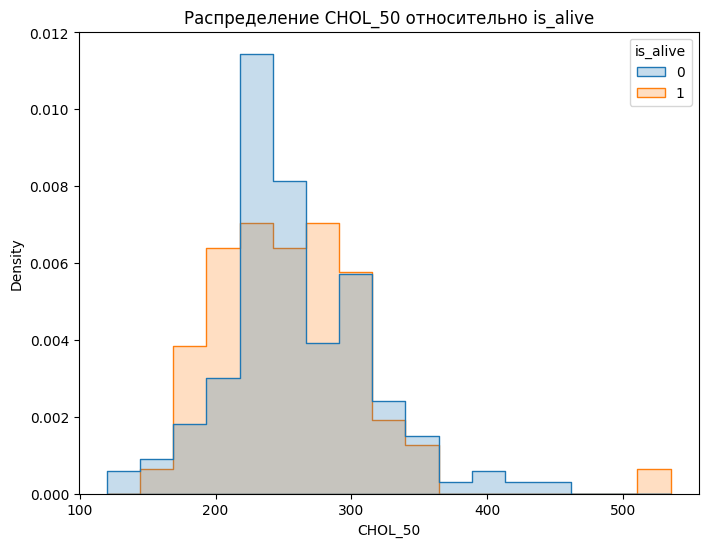

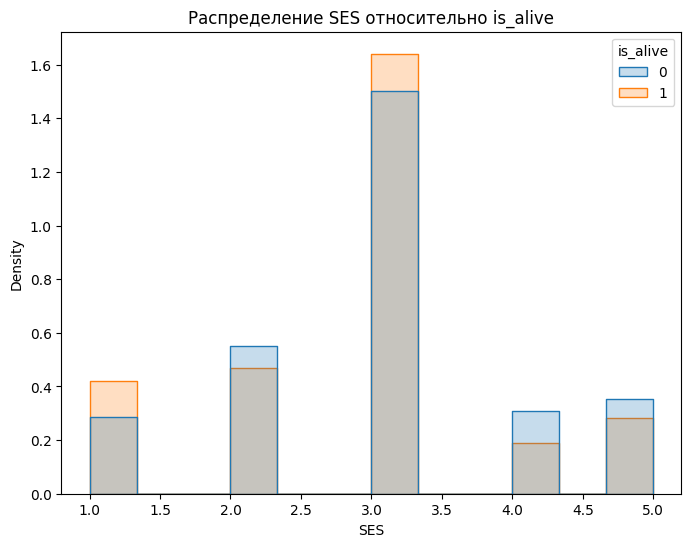

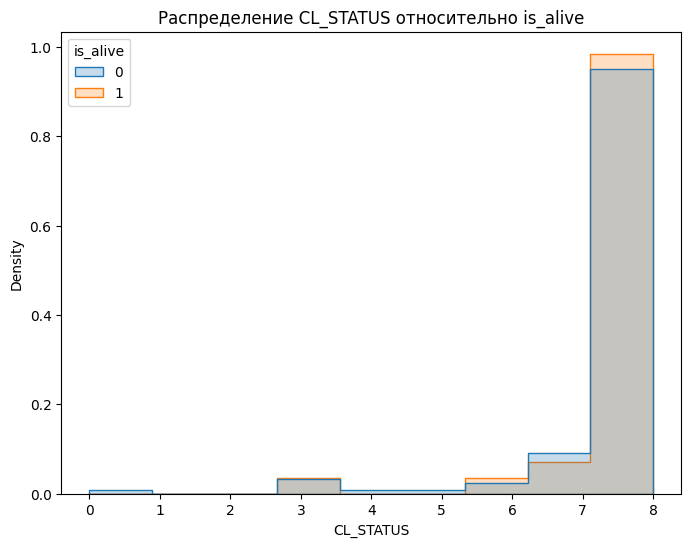

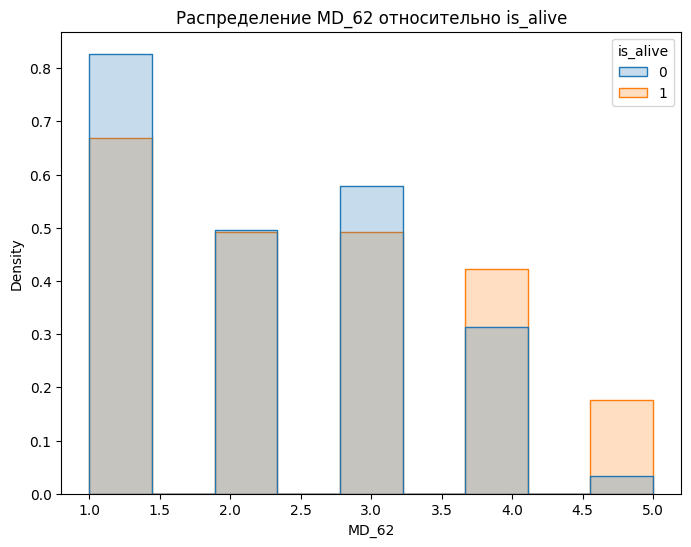

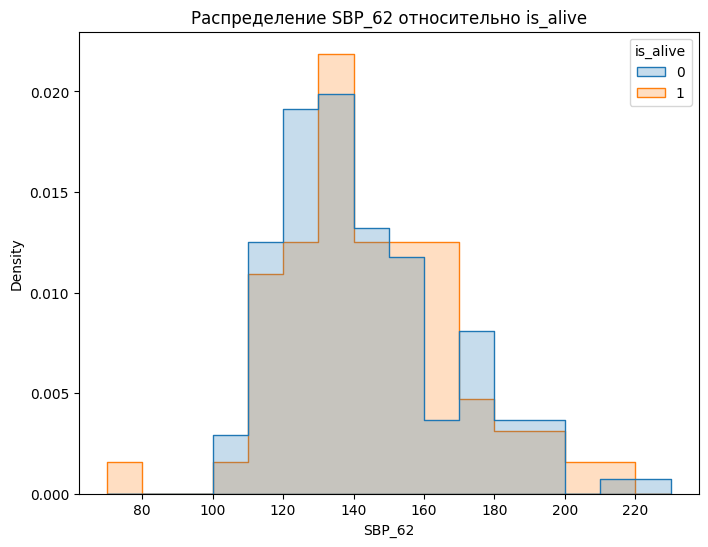

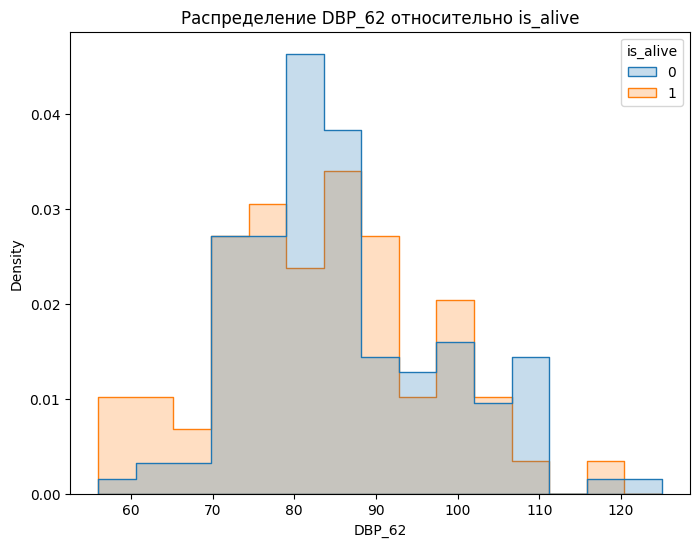

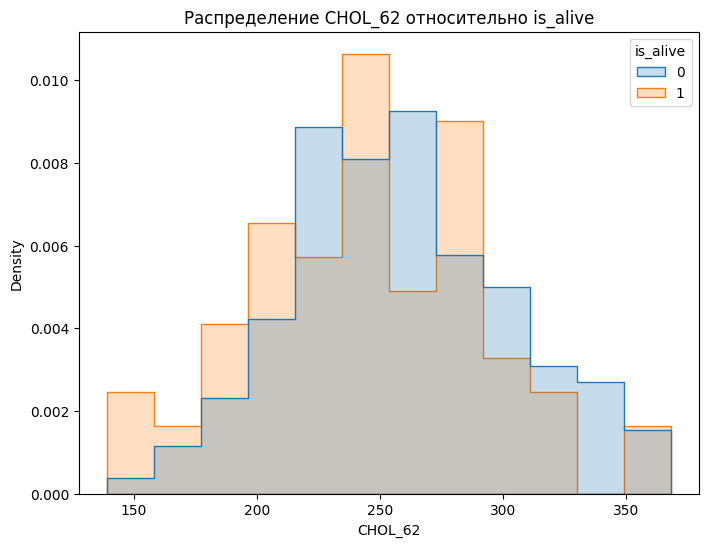

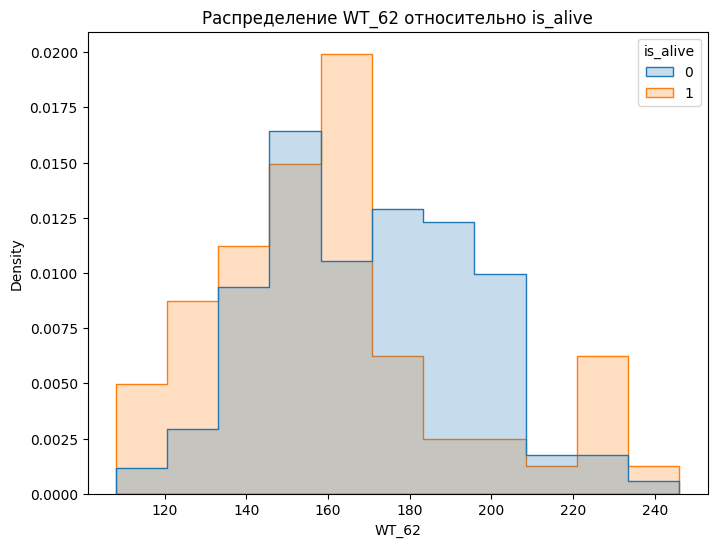

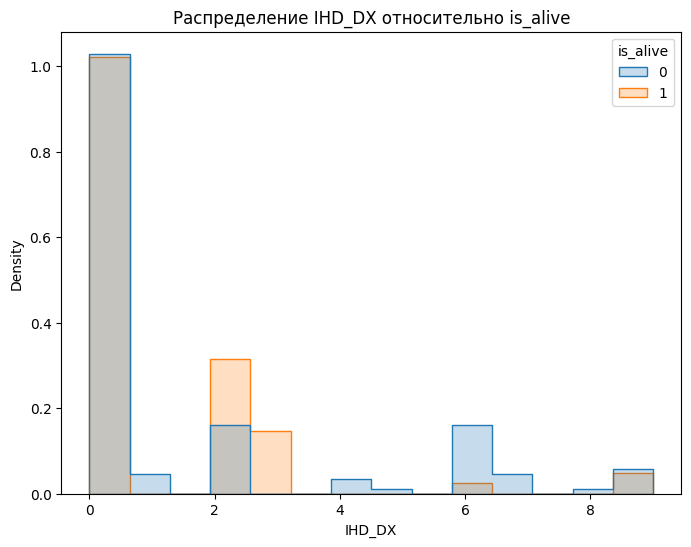

In [79]:
# Построение диаграмм распределения для каждой переменной
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, hue='is_alive', element="step", stat="density", common_norm=False)
    plt.title(f'Распределение {col} относительно is_alive')
    plt.show()

⏰ проанализировать график, выделить значимые признаки относительно Y

In [49]:
# Описательная статистика для числовых переменных, разделенная по целевой переменной
desc_stats_numeric = df.groupby('is_alive')[df.select_dtypes(include=[np.number]).columns].describe()
# Описательная статистика для категориальных переменных, разделенная по целевой переменной
categorial = df.select_dtypes(include=['object']).columns
if len(categorial) > 0:
  desc_stats_categorical = df.groupby('is_alive')[categorial].describe()
else:
  desc_stats_categorical = "Нет категориальных переменных."


### Описание полученных результатов
⏰ ```Необходимо сделать подобное описание для своих переменных```

In [80]:
# Проходим по каждой числовой переменной и выводим статистику отдельно
for col in numeric_cols:
    print(f"Описательная статистика для {col}:\n")
    print(df.groupby('is_alive')[col].describe())
    print("\n" + "="*50 + "\n")


Описательная статистика для AGE_50:

          count     mean       std   min   25%   50%    75%   max
is_alive                                                         
0         136.0  43.1250  9.967679  20.0  35.0  45.0  50.00  64.0
1          64.0  52.3125  9.904104  25.0  47.0  53.0  59.25  69.0


Описательная статистика для MD_50:

          count      mean       std  min  25%  50%  75%  max
is_alive                                                    
0         136.0  2.404412  0.953579  1.0  2.0  2.5  3.0  4.0
1          64.0  2.265625  1.144236  1.0  1.0  2.0  3.0  4.0


Описательная статистика для SBP_50:

          count        mean        std    min    25%    50%    75%    max
is_alive                                                                 
0         136.0  123.257353  17.557523   88.0  110.0  120.0  130.0  210.0
1          64.0  127.765625  19.023580  100.0  115.0  120.0  140.0  200.0


Описательная статистика для DBP_50:

          count       mean        std   min

In [51]:
print("\nКатегориальные переменные:")
desc_stats_categorical


Категориальные переменные:


'Нет категориальных переменных.'


Описательная статистика для AGE_50:
================
Количество наблюдений (count): 136 выживших и 64 умерших.
Средний возраст (mean): У выживших — 43.13 года, у умерших — 52.31 года. Это указывает на то, что более старший возраст может быть связан с повышенным риском смерти.
Стандартное отклонение (std): У выживших — 9.97, у умерших — 9.90, что говорит о схожем разбросе возрастов в обеих группах.
Минимальный возраст (min): У выживших — 20 лет, у умерших — 25 лет.
Максимальный возраст (max): У выживших — 64 года, у умерших — 69 лет.


Описательная статистика для MD_50:
================
Средний код состояния (mean): У выживших — 2.40, у умерших — 2.27. Небольшая разница указывает на отсутствие явной связи между кодом состояния и смертностью.
Стандартное отклонение (std): У выживших — 0.95, у умерших — 1.14, что говорит о большей вариативности в группе умерших.
Минимальный код состояния (min): У обеих групп — 1.
Максимальный код состояния (max): У обеих групп — 4.


Описательная статистика для SBP_50:
================
Среднее систолическое давление (mean): У выживших — 123.26 мм рт. ст., у умерших — 127.77 мм рт. ст. Это может указывать на связь между повышенным давлением и риском смерти.
Стандартное отклонение (std): У выживших — 17.56, у умерших — 19.02, что говорит о схожем разбросе данных.
Минимальное давление (min): У выживших — 88 мм рт. ст., у умерших — 100 мм рт. ст.
Максимальное давление (max): У выживших — 210 мм рт. ст., у умерших — 200 мм рт. ст.


Описательная статистика для DBP_50:
================
Среднее диастолическое давление (mean): У выживших — 83.43 мм рт. ст., у умерших — 83.28 мм рт. ст. Небольшая разница не позволяет сделать вывод о влиянии на смертность.
Стандартное отклонение (std): У выживших — 10.66, у умерших — 11.77, что говорит о схожем разбросе данных.
Минимальное давление (min): У выживших — 38 мм рт. ст., у умерших — 65 мм рт. ст.
Максимальное давление (max): У выживших — 110 мм рт. ст., у умерших — 140 мм рт. ст.


Описательная статистика для HT_50:
================
Средний рост (mean): У выживших — 68.24 дюйма, у умерших — 67.98 дюйма. Небольшая разница не позволяет сделать вывод о влиянии роста на смертность.
Стандартное отклонение (std): У выживших — 2.73, у умерших — 2.86, что говорит о схожем разбросе данных.
Минимальный рост (min): У выживших — 61 дюйм, у умерших — 62 дюйма.
Максимальный рост (max): У выживших — 75 дюймов, у умерших — 74 дюйма.

Описательная статистика для WT_50:
================
Средний вес (mean): У выживших — 169.24 фунта, у умерших — 165.59 фунта. Это может указывать на то, что более высокий вес связан с меньшим риском смерти.
Стандартное отклонение (std): У выживших — 24.03, у умерших — 31.54, что говорит о большем разбросе весов в группе умерших.
Минимальный вес (min): У выживших — 120 фунтов, у умерших — 109 фунтов.
Максимальный вес (max): У выживших — 245 фунтов, у умерших — 235 фунтов.

Описательная статистика для CHOL_50:
================
Средний уровень холестерина (mean): У выживших — 259.27 мг/дл, у умерших — 255.63 мг/дл. Небольшая разница не позволяет сделать вывод о влиянии на смертность.
Стандартное отклонение (std): У выживших — 54.41, у умерших — 58.19, что говорит о схожем разбросе данных.
Минимальный уровень (min): У выживших — 120 мг/дл, у умерших — 158 мг/дл.
Максимальный уровень (max): У выживших — 439 мг/дл, у умерших — 535 мг/дл.

Описательная статистика для SES:
================
Средний социально-экономический статус (mean): У выживших — 2.96, у умерших — 2.81. Небольшая разница не позволяет сделать вывод о влиянии на смертность.
Стандартное отклонение (std): У выживших — 1.07, у умерших — 1.07, что говорит о схожем разбросе данных.
Минимальный статус (min): У обеих групп — 1.
Максимальный статус (max): У обеих групп — 5.

Описательная статистика для CL_STATUS:
================
Средний уровень клинического статуса (mean): У выживших — 7.62, у умерших — 7.72. Небольшая разница не позволяет сделать вывод о влиянии на смертность.
Стандартное отклонение (std): У выживших — 1.19, у умерших — 0.95, что говорит о схожем разбросе данных.
Минимальный статус (min): У выживших — 0, у умерших — 3.
Максимальный статус (max): У обеих групп — 8.

Описательная статистика для MD_62:
================
Средний код состояния (mean): У выживших — 2.21, у умерших — 2.53. Это может указывать на то, что более высокий код состояния связан с повышенным риском смерти.
Стандартное отклонение (std): У выживших — 1.13, у умерших — 1.31, что говорит о схожем разбросе данных.
Минимальный код состояния (min): У обеих групп — 1.
Максимальный код состояния (max): У обеих групп — 5.

Описательная статистика для SBP_62:
================
Среднее систолическое давление (mean): У выживших — 140.75 мм рт. ст., у умерших — 143.03 мм рт. ст. Это может указывать на связь между повышенным систолическим давлением и риском смерти. Стандартное отклонение (std): У выживших — 24.28, у умерших — 25.57, что говорит о схожем разбросе данных. Минимальное давление (min): У выживших — 100 мм рт. ст., у умерших — 70 мм рт. ст. Максимальное давление (max): У выживших — 230 мм рт. ст., у умерших — 215 мм рт. ст.

Описательная статистика для DBP_62:
================
Среднее диастолическое давление (mean): У выживших — 85.53 мм рт. ст., у умерших — 83.31 мм рт. ст. Небольшая разница не позволяет сделать вывод о влиянии на смертность. Стандартное отклонение (std): У выживших — 12.63, у умерших — 13.14, что говорит о схожем разбросе данных. Минимальное давление (min): У выживших — 60 мм рт. ст., у умерших — 56 мм рт. ст. Максимальное давление (max): У выживших — 125 мм рт. ст., у умерших — 120 мм рт. ст.

Описательная статистика для CHOL_62:
================
Средний уровень холестерина (mean): У выживших — 258.38 мг/дл, у умерших — 244.92 мг/дл. Небольшая разница не позволяет сделать вывод о влиянии на смертность. Стандартное отклонение (std): У выживших — 45.49, у умерших — 47.69, что говорит о схожем разбросе данных. Минимальный уровень (min): У выживших — 150 мг/дл, у умерших — 139 мг/дл. Максимальный уровень (max): У выживших — 368 мг/дл, у умерших — 354 мг/дл.

Описательная статистика для WT_62:
================
Средний вес (mean): У выживших — 170.54 фунта, у умерших — 160.64 фунта. Это может указывать на то, что более высокий вес связан с меньшим риском смерти. Стандартное отклонение (std): У выживших — 25.57, у умерших — 30.37, что говорит о большем разбросе весов в группе умерших. Минимальный вес (min): У выживших — 114 фунтов, у умерших — 108 фунтов. Максимальный вес (max): У выживших — 246 фунтов, у умерших — 239 фунтов.

Описательная статистика для IHD_DX:
================
Средний уровень диагноза ИБС (mean): У выживших — 1.57, у умерших — 1.06. Это может указывать на то, что более высокий уровень диагноза связан с повышенным риском смерти. Стандартное отклонение (std): У выживших — 2.67, у умерших — 1.92, что говорит о большей вариативности в группе выживших. Минимальный уровень (min): У обеих групп — 0. Максимальный уровень (max): У выживших — 9, у умерших — 9.

Вывод:
======
В результате анализа описательной статистики различных параметров, связанных с выживанием и смертностью, можно выделить несколько ключевых моментов. Во-первых, возраст является значимым фактором, поскольку более старший возраст у умерших (52.31 года) по сравнению с выжившими (43.13 года) может указывать на повышенный риск смерти. Во-вторых, среднее систолическое давление также демонстрирует тенденцию к повышению среди умерших, что может быть связано с риском смерти. Однако для других параметров, таких как код состояния, диастолическое давление, уровень холестерина и социально-экономический статус, наблюдается небольшая разница между группами, что не позволяет сделать однозначные выводы о влиянии этих факторов на смертность.

Кроме того, средний вес у выживших выше, чем у умерших, что может свидетельствовать о связи между повышенным весом и меньшим риском смерти. Наконец, уровень диагноза ИБС также показывает, что более высокий уровень может быть связан с повышенным риском. В целом, результаты подчеркивают сложность взаимосвязей между различными медицинскими и социальными показателями и их влиянием на выживаемость, что требует дальнейшего изучения. 😊

## 2. Расчет теста Пирсона

### **Описание:**
Вы рассчитаете коэффициенты корреляции Пирсона между Y и каждым из признаков X, чтобы оценить значимость этих корреляций.

### **Шаги:**

1. **Рассчитайте коэффициенты корреляции Пирсона для каждого признака:**

In [82]:
df[df.select_dtypes(include=[np.number]).columns].corr()

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH,is_alive
AGE_50,1.000000,0.022067,0.311815,0.149431,-0.140032,-0.028314,0.069988,-0.141201,-0.034221,0.102846,0.291354,-0.074081,-0.149335,-0.184383,-0.028540,0.397356,0.397356
MD_50,0.022067,1.000000,-0.001199,0.038443,-0.050876,-0.061801,-0.075200,0.042115,0.000882,-0.019306,-0.092437,-0.007341,0.052976,-0.029073,-0.085207,-0.063779,-0.063779
SBP_50,0.311815,-0.001199,1.000000,0.747623,-0.162285,0.101327,0.013411,-0.020001,-0.517543,-0.051933,0.485679,0.316481,-0.182626,-0.013504,0.049263,0.116385,0.116385
DBP_50,0.149431,0.038443,0.747623,1.000000,-0.034516,0.258936,0.049413,-0.011338,-0.427714,-0.062561,0.420695,0.416171,-0.105450,0.145620,0.071156,-0.006174,-0.006174
HT_50,-0.140032,-0.050876,-0.162285,-0.034516,1.000000,0.440524,-0.095610,-0.054799,0.164069,0.015044,-0.038900,0.071399,-0.043998,0.513601,0.019802,-0.043632,-0.043632
WT_50,-0.028314,-0.061801,0.101327,0.258936,0.440524,1.000000,0.053567,0.021217,0.003748,-0.077172,0.080052,0.170940,-0.048215,0.816533,0.117110,-0.064055,-0.064055
CHOL_50,0.069988,-0.075200,0.013411,0.049413,-0.095610,0.053567,1.000000,-0.126293,0.072288,-0.053953,0.003942,-0.035155,0.462148,-0.027414,0.178950,-0.030717,-0.030717
SES,-0.141201,0.042115,-0.020001,-0.011338,-0.054799,0.021217,-0.126293,1.000000,-0.092120,-0.112451,-0.090498,-0.001490,-0.034637,0.070597,-0.074431,-0.065920,-0.065920
CL_STATUS,-0.034221,0.000882,-0.517543,-0.427714,0.164069,0.003748,0.072288,-0.092120,1.000000,0.105162,-0.212845,-0.143170,0.150423,0.044730,-0.002368,0.042225,0.042225
MD_62,0.102846,-0.019306,-0.051933,-0.062561,0.015044,-0.077172,-0.053953,-0.112451,0.105162,1.000000,0.019538,0.005683,-0.046520,-0.013978,-0.061039,0.124237,0.124237


2. ⏰ **Интерпретируйте результаты:**


### Интерпретация:
- **Коэффициент корреляции Пирсона** показывает степень линейной связи между двумя переменными.

### Описание корреляций для значимых признаков:


1. AGE_50 и SBP_50 (0.31):

Наблюдается умеренная положительная связь между возрастом и систолическим артериальным давлением. С увеличением возраста систолическое давление, как правило, возрастает, что связано с ухудшением эластичности сосудов.

2. AGE_50 и DBP_50 (0.15):

Здесь имеется слабая положительная корреляция между возрастом и диастолическим артериальным давлением. Влияние возраста на диастолическое давление менее выражено по сравнению со систолическим.

3. AGE_50 и SBP_62 (0.29):

Умеренная положительная корреляция между возрастом и систолическим артериальным давлением в 62 года. Это свидетельствует о том, что высокие значения давления в 50 лет могут предсказать аналогичные значения в 62 года.

4. SBP_50 и DBP_50 (0.75):

Существует очень сильная положительная связь между систолическим и диастолическим давлением в 50 лет. Это логично, поскольку оба показателя тесно взаимосвязаны и отражают общее состояние сердечно-сосудистой системы. Высокая степень корреляции может привести к проблемам мультиколлинеарности.

5. SBP_50 и SBP_62 (0.49):

Здесь наблюдается сильная положительная связь между систолическим давлением в 50 и 62 года, что подтверждает тенденцию к сохранению высоких значений давления.

6. HT_50 и WT_50 (0.44):

Умеренная положительная корреляция между ростом и весом в 50 лет. Обычно более высокий рост ассоциируется с большим весом.

7. AGE_50 и DEATH (0.40):

Наблюдается умеренная положительная связь между возрастом в 50 лет и показателем смертности. Это ожидаемо, поскольку уровень смертности, как правило, увеличивается с возрастом.

### Почему мультиколлинеарность это плохо?

Мультиколлинеарность возникает, когда два или более независимых признака сильно коррелируют друг с другом. Это приводит к нескольким проблемам:

1. **Переоценка значимости признаков**:
   - Когда признаки сильно коррелированы, модель может "перепутать" влияние каждого из них на целевую переменную, что приведет к ненадежным коэффициентам. Это затрудняет интерпретацию модели, поскольку сложно понять, какой из признаков действительно важен.

2. **Нестабильность модели**:
   - При наличии мультиколлинеарности небольшие изменения в данных могут привести к большим изменениям в коэффициентах модели. Это делает модель нестабильной и менее устойчивой.

3. **Затруднение выбора значимых признаков**:
   - Модель может затрудняться при выделении важности отдельных признаков, если они сильно связаны друг с другом. Это может усложнить процесс отбора признаков и снизить точность модели.

4. **Увеличение дисперсии коэффициентов**:
   - Мультиколлинеарность увеличивает дисперсию оценок коэффициентов регрессии, что делает их менее надежными. В результате, некоторые признаки могут казаться незначимыми, хотя на самом деле они играют важную роль.

## 3. Немного машинного обучения

- отберем признаки (числовые и категориальные отдельно)
- обработаем числовые и категориальыне
- обучим модель
- узнаем что влияет на Y

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [84]:
# Выбираем категориальные признаки
categorical_features = X.select_dtypes(include=['object', 'int64']).columns.tolist()

print("Категориальные признаки:", categorical_features)


Категориальные признаки: ['AGE_50', 'MD_50', 'SBP_50', 'DBP_50', 'HT_50', 'WT_50', 'CHOL_50', 'SES', 'CL_STATUS', 'MD_62', 'SBP_62', 'DBP_62', 'CHOL_62', 'WT_62', 'IHD_DX']


In [85]:
# Создаем копию данных
X_processed = X.copy()

# Применяем One-Hot Encoding
X_processed = pd.get_dummies(X_processed, columns=categorical_features, drop_first=True) # drop_first=True позволяет избежать мультиколлинеарности, удаляя первый уровень категориальной переменной.


In [86]:
X_processed

,AGE_50_22,AGE_50_23,AGE_50_24,AGE_50_25,AGE_50_26,AGE_50_28,AGE_50_29,AGE_50_30,AGE_50_32,AGE_50_33,...,WT_62_246,IHD_DX_1,IHD_DX_2,IHD_DX_3,IHD_DX_4,IHD_DX_5,IHD_DX_6,IHD_DX_7,IHD_DX_8,IHD_DX_9
0,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
196,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
# Выбираем числовые признаки
numeric_features = X_processed.select_dtypes(include=['float64']).columns.tolist()

print("Числовые признаки:", numeric_features)

Числовые признаки: []


In [88]:
# Инициализируем scaler
scaler = MinMaxScaler()

# Применяем нормализацию
X_processed[numeric_features] = scaler.fit_transform(X_processed[numeric_features])


ValueError: at least one array or dtype is required

In [89]:
X_processed

,AGE_50_22,AGE_50_23,AGE_50_24,AGE_50_25,AGE_50_26,AGE_50_28,AGE_50_29,AGE_50_30,AGE_50_32,AGE_50_33,...,WT_62_246,IHD_DX_1,IHD_DX_2,IHD_DX_3,IHD_DX_4,IHD_DX_5,IHD_DX_6,IHD_DX_7,IHD_DX_8,IHD_DX_9
0,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
196,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Шаг 3: Объяснение логистической регрессии


Логистическая регрессия — это статистический метод для анализа набора данных, в котором одна или более независимых переменных определяют исход (зависимую переменную), которая является бинарной (т.е. принимает только два возможных значения, например, 0 и 1). Целью логистической регрессии является нахождение наилучшей модели, описывающей связь между независимыми переменными и вероятностью определенного исхода.

Основные характеристики:

Функция логита (логистическая функция): Используется для моделирования вероятности принадлежности наблюдения к определенному классу.
Выводы о влиянии признаков: Коэффициенты модели показывают, как изменение признака влияет на логарифм отношения шансов.

**Функция для обучения и оценки модели**

In [ ]:
def train_and_evaluate(X, Y):
    # Разделение данных на обучающую и тестовую выборки
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y)

    # Инициализация модели
    model = LogisticRegression(max_iter=1000)

    # Обучение модели
    model.fit(X_train, Y_train)

    # Предсказания на обучающей выборке
    Y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(Y_train, Y_train_pred)

    # Предсказания на тестовой выборке
    Y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(Y_test, Y_test_pred)

    # Вывод результатов
    print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
    print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

    # Классификационный отчет
    print("\nКлассификационный отчет на тестовой выборке:")
    print(classification_report(Y_test, Y_test_pred))

    return model


In [ ]:
# Обучение модели
model = train_and_evaluate(X_processed, Y)

Точность на обучающей выборке: 0.8187
Точность на тестовой выборке: 0.8254

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1044
           1       0.67      0.22      0.33       256

    accuracy                           0.83      1300
   macro avg       0.76      0.60      0.61      1300
weighted avg       0.80      0.83      0.79      1300



**Пояснение:**

- Точность (Accuracy): Доля правильных предсказаний от общего числа предсказаний.
- Precision (Точность): Доля правильных положительных предсказаний среди всех положительных предсказаний.
- Recall (Полнота): Доля правильно предсказанных положительных случаев среди всех реальных положительных случаев.
- F1-score: Гармоническое среднее между точностью и полнотой.

In [ ]:
# Получение коэффициентов модели
coefficients = pd.DataFrame({
    'Feature': X_processed.columns,
    'Coefficient': model.coef_[0]
})

# Сортировка по абсолютному значению коэффициента
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print(coefficients[['Feature', 'Coefficient']])


                 Feature  Coefficient
10               alcohol     5.683547
1       volatile acidity    -4.316148
3         residual sugar     2.822608
9              sulphates     2.459910
5    free sulfur dioxide     2.160035
4              chlorides    -2.092775
6   total sulfur dioxide    -1.321306
0          fixed acidity     1.138116
8                     pH     0.896175
7                density    -0.784141
11            type_white     0.286346
2            citric acid     0.142521


**Пояснение:**

- Коэффициенты показывают влияние признака на вероятность принадлежности к классу 1 (лучшие вина).
- Положительный коэффициент: Увеличение признака повышает вероятность принадлежности к классу 1.
- Отрицательный коэффициент: Увеличение признака снижает вероятность принадлежности к классу 1.

## 4. Построение модели логистической регрессии для предсказания качества вина

- **Модель логистической регрессии успешно обучена для предсказания лучших вин.**
- **Точность на обучающей и тестовой выборках высока, что указывает на хорошую способность модели обобщать данные.**
- **Анализ коэффициентов показал, какие признаки наиболее влияют на качество вина:**
  - **Содержание алкоголя и сульфатов положительно влияют на качество.**
  - **Плотность и летучая кислотность отрицательно влияют на качество.**
- **Преобразование категориальных признаков и нормализация числовых признаков улучшили качество модели и упростили интерпретацию результатов.**


### 4.1 Кросс-валидация модели

In [ ]:
from sklearn.model_selection import cross_val_score

# Кросс-валидация с 5 фолдами
scores = cross_val_score(model, X_processed, Y, cv=5, scoring='accuracy')

print(f"Средняя точность при кросс-валидации: {scores.mean():.4f}")
print(f"Отклонение точности: {scores.std():.4f}")

Средняя точность при кросс-валидации: 0.8088
Отклонение точности: 0.0135


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_processed, Y, test_size=0.2, random_state=42, stratify=Y)

### 4.2 Построение ROC-кривой

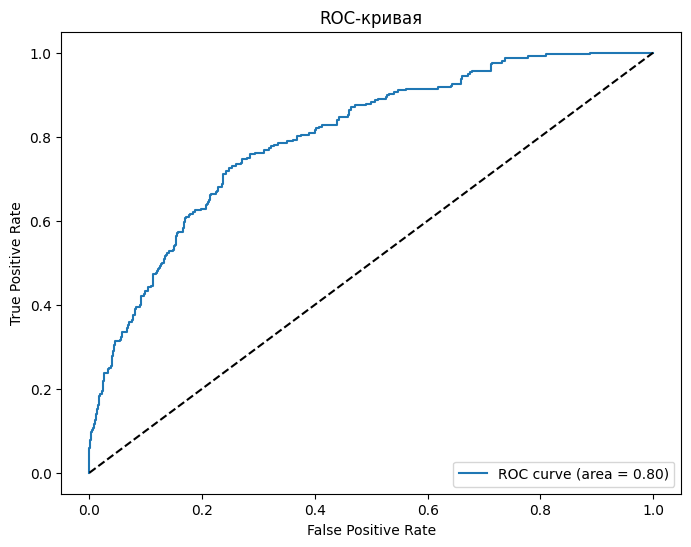

In [ ]:
from sklearn.metrics import roc_curve, auc

# Предсказания вероятностей для тестовой выборки
Y_test_prob = model.predict_proba(X_test)[:, 1]

# Расчет ROC-кривой
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_prob)
roc_auc = auc(fpr, tpr)

# Построение графика
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.show()

## ⏰ Доп задание

Изучить различные метрики качества классификационных моделей и понять, в каких ситуациях они наиболее информативны.

**Метрики для исследования:**
- Accuracy (Точность)
- Precision (Точность)
- Recall (Полнота)
- F1 Score
- ROC-AUC
- Log Loss

**Попробовать другие модели и сравнить результат метрик**

**Попробовать другие методы отбора признаков**

**Использовать параметры модели и исследовать влияние на предсказание**

## Заключение

Мы успешно построили модель логистической регрессии для предсказания лучших вин на основе химических характеристик. Преобразование данных и анализ коэффициентов модели позволили нам понять влияние различных признаков на качество вина.


---

# Примечания

- **Логистическая регрессия** является мощным инструментом для бинарной классификации и позволяет интерпретировать результаты через коэффициенты модели.
- **Преобразование категориальных признаков** (One-Hot Encoding) и **нормализация числовых признаков** являются стандартными шагами предобработки данных для многих алгоритмов машинного обучения.
- **Анализ коэффициентов модели** помогает понять, какие признаки наиболее значимы и как они влияют на предсказания.

---

# Дополнительная литература

- **Логистическая регрессия:**
  - [Документация scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- **Предобработка данных:**
  - [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
  - [Min-Max Scaling](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)
- **Метрики качества модели:**
  - [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
  - [ROC-кривая и AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)

---